# `20261003`
## `gs078`: 
### export some exemplary ATP/motor trace(s); define trial functions cleanly corresponding to those in COMSOL

## Imports

In [1]:
#for reading files
import glob
import tifffile

#math computation and data organization
import numpy as np
import math
import scipy
from scipy.ndimage import binary_erosion, binary_fill_holes
from scipy import optimize
from scipy.optimize import curve_fit
import pandas as pd

# For loading bars
from tqdm.notebook import tqdm as tqdm

#For image plotting
import skimage.io

#For identifying aster center
from skimage.filters import threshold_otsu, gaussian, threshold_mean
from skimage.measure import regionprops
import cv2

#for fitting
from lmfit import minimize, Parameters, fit_report

#for image registration
from skimage.registration import phase_cross_correlation
import os

#Matplotlib plotting packages
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import patches
from matplotlib import gridspec

import seaborn as sns
sns.set_context("poster")
sns.set_style("ticks")

#Movie
import celluloid as cell
import matplotlib.animation as animation

#for saving data
import csv
import h5py

#custom analysis packages
import aster_packages as ap #### commented out 20241114 since lucida fonts are not installed...

# Thing to enable lovely parallelization
import concurrent.futures

# Enable repeat from itertools for parallel
import itertools

#time elements for testing runtimes and using todays date
import time
from datetime import datetime

___

## Extract a "poster child" trace
* The main text Fig. 3 plot traces can be produced from notebook code cells originally found in `home/aduarte/am_atp/analysis/aster/20250115_paraAster-ftns_postBleach.ipynb`.

#### helper functions needed

In [9]:
def read_h5py(path_name, excludes=[], includes=[]):
    # Glob for directory parsing to get all .h5 files in the specified path
    h5files = glob.glob(path_name + '/*.h5')
    for excl in excludes:
        h5files=[file for file in h5files if excl not in file]
    for incl in includes:
        h5files=[file for file in h5files if incl in file]

    print(len(h5files))
        
    #print("HDF5 files found:", h5files)
    
    # Dictionary to store arrays from each file
    all_data = {}
    
    for file in h5files:
        file_data = []  # List to hold datasets for the current file
        
        with h5py.File(file, 'r') as h5file:
            def load_data(name, obj):
                if isinstance(obj, h5py.Dataset):
                    file_data.append(obj[:])  # Append dataset as a NumPy array
            
            # Visit all datasets in the file and load them into file_data
            h5file.visititems(load_data)
        
        #slice by 8 since the date has 8 didgits
        field_name = file.split('.h5')[0].split('tif')[-1][15:] #BRO, 15 is the number of digits in how we save datetime -> 20241114_201131 (formerly we had 8 since we didnt include time)
        #print(file + '\n')
        #print(field_name+ '\n')
            
        # Add this file's data to all_data with the filename as the key
        all_data[field_name] = file_data[0]
        
        
    return all_data

##
def makeImFromValsList(valuesList, mask_coords, imshape):
    """ valuesList: numTimepoints x numValues, such that valuesList[t,:] is the list of values we populate in the returned image/array
        mask_coords: tuple of length 2; the first entry is 1d array of rowNums and the second entry is 1d array of colNums, of length = numValues (defined in mask)
        imshape: numImgRows x numImgCols.
        
        Returns imgArrayTotal = (numTimepoints x numImgRows x numImgCols) array where things are zero when outside the mask and otherwise populated by the provided valuesList in appropriate positions.
    """
    imgArrayTotal = np.zeros((len(valuesList), imshape[0], imshape[1]))
    for t in range(len(valuesList)):
        imgArrayTotal[t,mask_coords[0], mask_coords[1]]=valuesList[t,:]
    
    return imgArrayTotal

##
def cvatCentandRad(gname, annotPath, imshape):
    annotdf = grabxml(annotPath)
    source = findmp4NameFromGname(gname)
    annotdf_subset = annotdf[annotdf['task_source']==source]
 
    cvatframes = np.array(annotdf_subset['frame']-annotdf_subset['frame'].max() + annotdf_subset['task_stop_frame'])
    firstkeyframe = cvatframes.min()
    
    firstFramesCenters = np.array([[imshape[1]/2,imshape[0]/2]]*firstkeyframe)
    cvatCenters =  np.array([annotdf_subset['cx'], annotdf_subset['cy']]).T
    centers = np.concat((firstFramesCenters, cvatCenters))
    
    firstFramesLengths = np.array([[np.nan,np.nan]]*firstkeyframe)
    cvatAxesLengths = np.array([annotdf_subset['rx'], annotdf_subset['ry']]).T
    axesLengths = np.concat((firstFramesLengths, cvatAxesLengths))
     
    
    return centers, axesLengths

##
def min_radius(mango_mask, centers):
    mango_skin_coords = find_contour(mango_mask)
    #reshapes stuff and broadcasts to do subtraction
    dists = np.sqrt(np.sum((mango_skin_coords[:, np.newaxis, :] - centers[np.newaxis, :, :])**2, axis=2))
    #find the minimum distance
    min_dist = np.min(dists)
    # #find the time and position corresponding to the minimum distance
    # min_dist_point, min_dist_time = np.where(dists==min_dist)
    # #find the coordinate of the minimimum distance
    # min_dist_coord = mango_skin_coords[min_dist_point]
    return min_dist

##
import xml.etree.ElementTree as ET

# Load XML
annotPath = '../../data/aster/2023-12_NCD_Aster_centerInfo/annotations.xml'

def grabxml(annotPath):
    tree = ET.parse(annotPath)  # Replace with actual filename
    root = tree.getroot()
    
    # --- Step 1: Extract task info indexed by task ID ---
    task_data = {}
    for task in root.findall(".//task"):
        task_id = task.find("id").text
        task_data[task_id] = {
            "task_start_frame": int(task.find("start_frame").text),
            "task_stop_frame": int(task.find("stop_frame").text),
            "task_source": task.find("source").text
        }
    
    # --- Step 2: Extract ellipse data inside each track ---
    all_ellipses = []
    
    for track in root.findall("track"):
        track_attrs = track.attrib
        task_id = track_attrs.get("task_id")
        
        # Get task info by task_id
        task_info = task_data.get(task_id, {})
    
        for ellipse in track.findall("ellipse"):
            ellipse_attrs = ellipse.attrib
    
            row = {
                **track_attrs,
                **ellipse_attrs,
                **task_info
            }
    
            all_ellipses.append(row)
    
    # --- Step 3: Convert to DataFrame ---
    annotdf = pd.DataFrame(all_ellipses)
    
    # Optional: convert numeric columns
    for col in ['frame', 'cx', 'cy', 'rx', 'ry', 'z_order', 'task_start_frame', 'task_stop_frame']:
        if col in annotdf.columns:
            annotdf[col] = pd.to_numeric(annotdf[col], errors='coerce')

    return annotdf

# # View result
# print(annotdf.head())

##
def findmp4NameFromGname(gname):
    date = gname.split('assay_')[1].split('/')[0]
    rep = gname.split('/')[-1].split('_MMStack')[0].split('A81D_')[1]
    pos = gname.split('/')[-1].split('MMStack_')[1].split('.ome')[0]
    if 'uM_Ncd' in gname:
        mot = gname.split('uM_Ncd')[0].split('_')[-1]
    elif 'uM_NCD' in gname:
        mot = gname.split('uM_NCD')[0].split('_')[-1]
    atp = gname.split('ATP')[0].split('_')[-1]
    
    mp4name = date+'_r'+rep+'_'+pos+'_mot'+mot+'_atp'+atp+'.mp4'
    return mp4name

## 
def find_contour(mask):
    #Find contours of binary image
    contours, heirarchy = cv2.findContours(mask.astype(np.uint8), 1, 2)
    #iterate through contours (for most connected region)
    max_area = 0
    max_index = None
    for j, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > max_area:
            max_area = area
            max_index = j

    #Find the coordinates of the illumination pattern contour
    cnt = contours[max_index]
    cnt = np.array(cnt)
    cnt = np.squeeze(cnt)
    return cnt

In [10]:
### Do the import

#gname_pc = '../../data/aster/Ncd_Aster_assay_12-12-2023/20sInterval_0.6uM_NCD_dimers_500uMATP_1.3uM_tubulin_2.8uM_A81D_2/20sInterval_0.6uM_NCD_dimers_500uMATP_1.3uM_tubulin_2.8uM_A81D_2_MMStack_Pos1.ome.tif'
gname_pc = '../../data/aster/Ncd_Aster_assay_12-11-2023/20sInterval_0.6uM_NCD_dimers_500uMATP_1.3uM_tubulin_2.8uM_A81D_1/20sInterval_0.6uM_NCD_dimers_500uMATP_1.3uM_tubulin_2.8uM_A81D_1_MMStack_Pos2.ome.tif'

h5spath_pc=gname_pc.split('data')[0]+'analyzed_data'+gname_pc.split('data')[1]+'/'
h5dic_pc = read_h5py(h5spath_pc)

ATP_conc_ims_pc = makeImFromValsList(h5dic_pc['ATP'], h5dic_pc['mask_coords'], h5dic_pc['imshape'])
mot_conc_ims_pc = makeImFromValsList(h5dic_pc['mot'], h5dic_pc['mask_coords'], h5dic_pc['imshape'])
mango_mask_pc = makeImFromValsList(np.ones((len(h5dic_pc['mot']), len(h5dic_pc['mask_coords'][0]))), h5dic_pc['mask_coords'], h5dic_pc['imshape'])[0].astype('int')

centers_pc, axesLengths_pc = cvatCentandRad(gname_pc, annotPath, ATP_conc_ims_pc[0].shape)
min_dist_pc = min_radius(mango_mask_pc, centers_pc)
side_length_pc = int(min_dist_pc/np.sqrt(2))

um_per_pixel=0.59
winsize_um = side_length_pc*um_per_pixel
extent = [-winsize_um, winsize_um, -winsize_um, winsize_um]

18


/home/aduarte/am_atp/analysis/aster/ipykernel_382349/1785102370.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


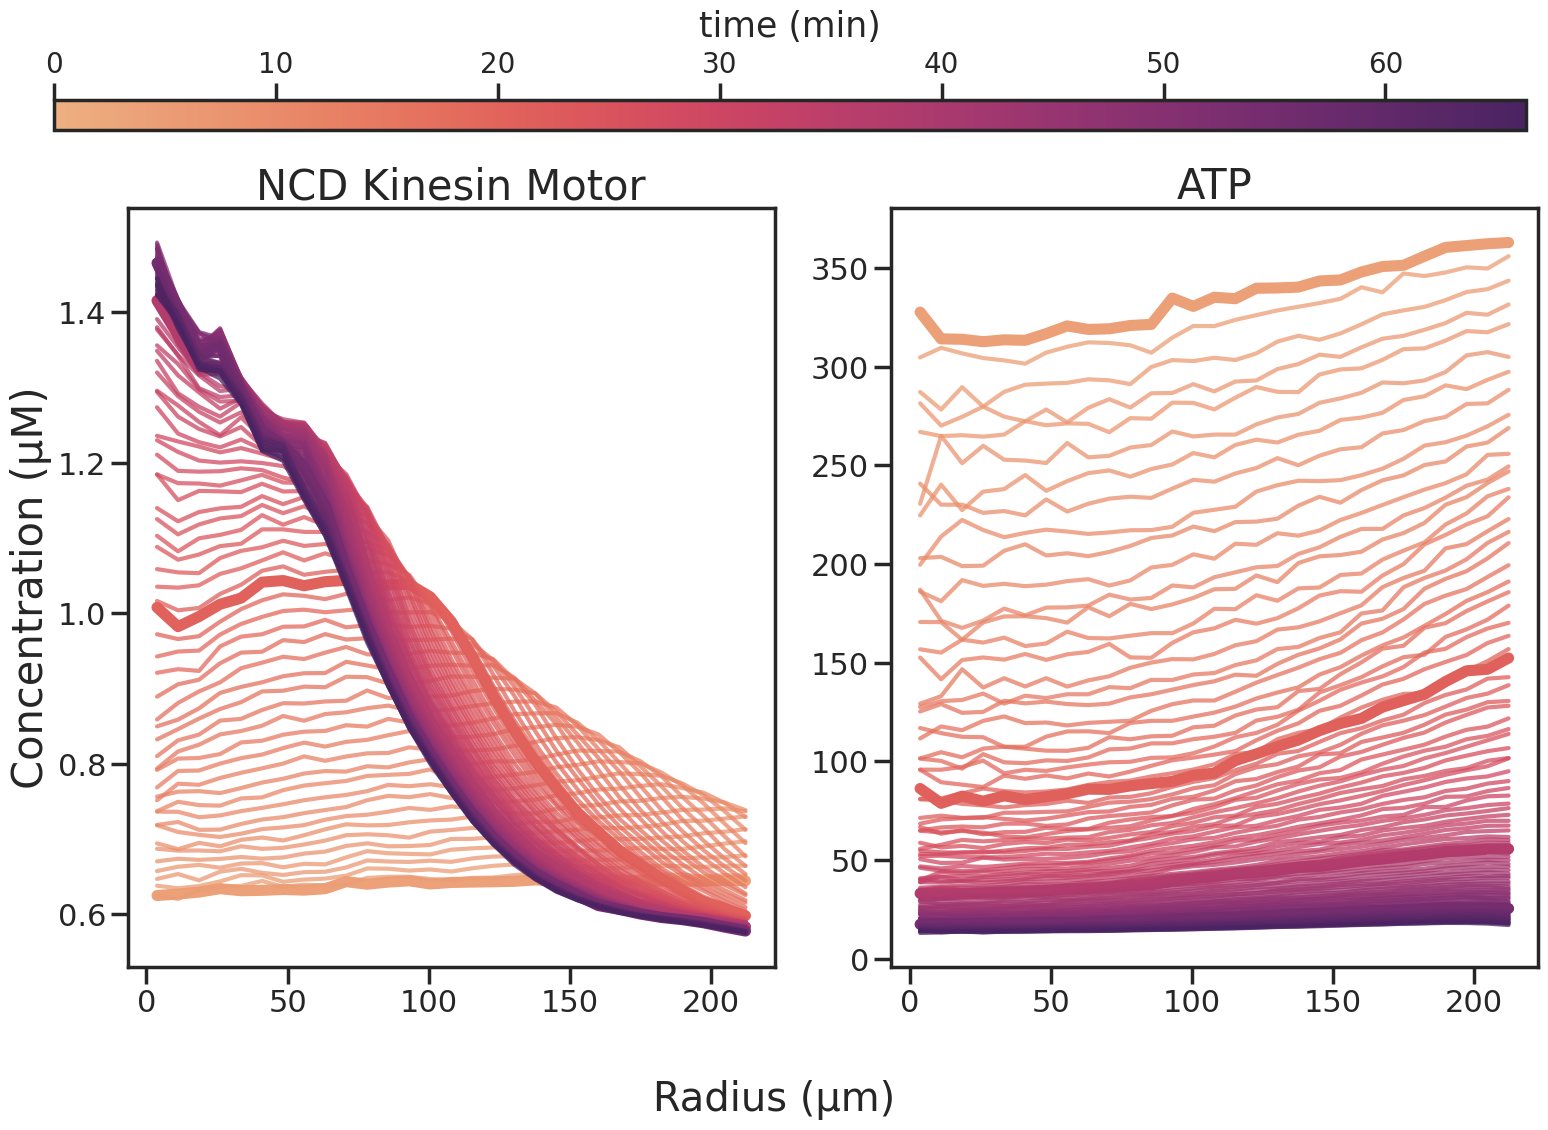

In [12]:
## Make the plot
global_time=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min()]), vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max()]))(time))

fig, ax = plt.subplots(1, 2, figsize=(16,10))
for t, time in enumerate(h5dic_pc['timesMot'][12::2]):
    if np.isin(t*2+12, [12, 62, 112, 162]):
        ax[0].plot(h5dic_pc['all_rMotbins'][t*2+12],
                 h5dic_pc['all_rMotavgs'][t*2+12], 
                 alpha=1,
                 lw=8,
                 color=global_time(time))
    else:
        ax[0].plot(h5dic_pc['all_rMotbins'][t*2+12],
                 h5dic_pc['all_rMotavgs'][t*2+12], 
                 alpha=0.75,
                 color=global_time(time))


for t, time in enumerate(h5dic_pc['timesATP'][12::2]):
    if np.isin(t*2+12, [12, 62, 112, 162]):
        ax[1].plot(h5dic_pc['all_rATPbins'][t*2+12]*6, #since downsampled by 6
                               h5dic_pc['all_rATPavgs'][t*2+12], 
                               alpha=1, 
                               lw=8,
                               color=global_time(time))#sns.color_palette("flare", as_cmap=True)(time/rMotmids.shape[0]), lw=2)        
    else:
        ax[1].plot(h5dic_pc['all_rATPbins'][t*2+12]*6, #since downsampled by 6
                               h5dic_pc['all_rATPavgs'][t*2+12], 
                               alpha=0.75, 
                               color=global_time(time))

ax[0].set_ylabel('Concentration (µM)', fontsize=30)
fig.supxlabel('Radius (µm)')
ax[1].set_xlim(ax[0].set_xlim())

ax[0].set_title('NCD Kinesin Motor', fontsize=30)
ax[1].set_title('ATP', fontsize=30)

# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)
#fig.subplots_adjust(right=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # horizontal [left, bottom, width, height]
#cax = fig.add_axes([1, 0.05, 0.03, 0.91])  # vertical [left, bottom, width, height]

# Create the colorbar
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(comsol_time_ls)/60, 
#                                                                  vmax=max(comsol_time_ls)/60)),
#                     cax=cax, orientation='vertical')

# Create an axis for the colorbar that spans all columns
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(h5dic_pc['timesMot'])/60, 
                                                                 vmax=max(h5dic_pc['timesMot'])/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)




fig.tight_layout()

#plt.savefig(h5spath_pc+'20250629_MotorATPTraces_postBleachCvat_12-11-2023_r1_Pos2.pdf', bbox_inches='tight', transparent=True)
#plt.savefig('20250629_MotorATPTraces_postBleachCvat_12-11-2023_r1_Pos2.pdf', bbox_inches='tight')

In [44]:
list(h5dic_pc.keys())

['ATPShells',
 'timesMot',
 'ATP_shell_vol_L',
 'timesATP',
 'imshape',
 'Mot_shell_vol_L',
 'ATP_centCrop',
 'MotShells',
 'timesPower',
 'mot_centCrop',
 'all_rMotavgs',
 'ATP',
 'all_rMotbins',
 'mask_coords',
 'powerShells',
 'mot',
 'all_rATPbins',
 'all_rATPavgs']

In [42]:
### Try exporting in a useable format
import pandas as pd

rows=[]; #preallocate

# just a convenient slice at time 0; multiply by 6 for 6-fold spatial downsampling; remember to convert to µm
radii=h5dic_pc['all_rATPbins'][0]*6*um_per_pixel 

startTimeIdx=12
for t in range(startTimeIdx, len(h5dic_pc['timesMot'])-1):
    for r, atp, mot in zip(radii, h5dic_pc['all_rATPavgs'][t], h5dic_pc['all_rMotavgs'][t]):
        rows.append({
            'r (µm)': r,
            't (s)': h5dic_pc['timesATP'][t],
            'ATP (µM)': atp,
            'motors (µM)': mot
        })

compiledPCdf = pd.DataFrame(rows)
compiledPCdf
    



,r (µm),t (s),ATP (µM),motors (µM)
0,2.197241,250.0,327.669431,0.625147
1,6.591724,250.0,314.097222,0.627098
2,10.986207,250.0,313.885121,0.629670
3,15.380690,250.0,312.655814,0.634243
4,19.775172,250.0,313.613832,0.631511
...,...,...,...,...
5418,107.664828,3970.0,17.910645,0.592443
5419,112.059310,3970.0,18.120282,0.589445
5420,116.453793,3970.0,18.084873,0.585050
5421,120.848276,3970.0,17.777958,0.580271


In [43]:
compiledPCdf.to_csv("20261004_exportMainFig3pcAsterProfileAsDF.csv", index=False)

In [45]:
h5dic_pc['timesMot'][:155]

array([   0.,   20.,   40.,   60.,   80.,  100.,  120.,  140.,  160.,
        180.,  200.,  220.,  240.,  260.,  280.,  300.,  320.,  340.,
        360.,  380.,  400.,  420.,  440.,  460.,  480.,  500.,  520.,
        540.,  560.,  580.,  600.,  620.,  640.,  660.,  680.,  700.,
        720.,  740.,  760.,  780.,  800.,  820.,  840.,  860.,  880.,
        900.,  920.,  940.,  960.,  980., 1000., 1020., 1040., 1060.,
       1080., 1100., 1120., 1140., 1160., 1180., 1200., 1220., 1240.,
       1260., 1280., 1300., 1320., 1340., 1360., 1380., 1400., 1420.,
       1440., 1460., 1480., 1500., 1520., 1540., 1560., 1580., 1600.,
       1620., 1640., 1660., 1680., 1700., 1720., 1740., 1760., 1780.,
       1800., 1820., 1840., 1860., 1880., 1900., 1920., 1940., 1960.,
       1980., 2000., 2020., 2040., 2060., 2080., 2100., 2120., 2140.,
       2160., 2180., 2200., 2220., 2240., 2260., 2280., 2300., 2320.,
       2340., 2360., 2380., 2400., 2420., 2440., 2460., 2480., 2500.,
       2520., 2540.,

In [46]:
h5dic_pc['timesMot']

array([   0.,   20.,   40.,   60.,   80.,  100.,  120.,  140.,  160.,
        180.,  200.,  220.,  240.,  260.,  280.,  300.,  320.,  340.,
        360.,  380.,  400.,  420.,  440.,  460.,  480.,  500.,  520.,
        540.,  560.,  580.,  600.,  620.,  640.,  660.,  680.,  700.,
        720.,  740.,  760.,  780.,  800.,  820.,  840.,  860.,  880.,
        900.,  920.,  940.,  960.,  980., 1000., 1020., 1040., 1060.,
       1080., 1100., 1120., 1140., 1160., 1180., 1200., 1220., 1240.,
       1260., 1280., 1300., 1320., 1340., 1360., 1380., 1400., 1420.,
       1440., 1460., 1480., 1500., 1520., 1540., 1560., 1580., 1600.,
       1620., 1640., 1660., 1680., 1700., 1720., 1740., 1760., 1780.,
       1800., 1820., 1840., 1860., 1880., 1900., 1920., 1940., 1960.,
       1980., 2000., 2020., 2040., 2060., 2080., 2100., 2120., 2140.,
       2160., 2180., 2200., 2220., 2240., 2260., 2280., 2300., 2320.,
       2340., 2360., 2380., 2400., 2420., 2440., 2460., 2480., 2500.,
       2520., 2540.,

## now wrestling with ana's trial functions,
* Originally defined in `20260406_paraAster_MT.ipynb` notebook.

In [48]:
## Ana's original functions in the cell
def sigmoid(arr, a, b, c, d):
    return a/(1+np.exp((arr - b)/c)) + d
def fitSigmoid(x, y, p0):
    param,_ = curve_fit(sigmoid, x, y, p0)
    return param

def quadratic(arr, a, b, c):
    return a*arr**2 + b*arr + c
def fitQuadratic(x, y, p0):
    param,_ = curve_fit(quadratic, x, y, p0)
    return param

def linear(arr, a, b):
    return a*arr + b
def fitLinear(x, y, p0):
    param,_ = curve_fit(linear, x, y, p0)
    return param
    
def exponential(arr, a, b, c):
    return a*np.exp(-arr/b)+c
def fitExponential(x, y, p0):
    param,_ = curve_fit(exponential, x, y, p0)
    return param

def processDF(filename):
    molperm3_to_uM = 1e3
    mtoum = 1e6
    comsol_file_path = "../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/"
    comment = '%'
    # constant gamma, motors as it has been
    tmepdf = pd.read_csv(comsol_file_path + filename, comment=comment, names=["position (µm)", "ATP (µM)"])
    tmepdf['ATP (µM)'] = tmepdf['ATP (µM)']*molperm3_to_uM
    tmepdf['position (µm)'] = tmepdf['position (µm)']*mtoum
    
    t_start = 0 #initial time
    t_end = 200*20 # final time
    spacing = 120 # seconds between each measurement
    interval = 1 #plotting interval
    
    numb_times = int((t_end-t_start)/spacing)+1
    
    comsol_times = np.linspace(t_start, t_start+spacing*(numb_times-1), numb_times) #given in s
    tot_points = len(tmepdf['position (µm)'])
    numb_points = int(tot_points/numb_times)
    
    comsol_time_ls = []
    for t in comsol_times:
        for i in range(numb_points):
            comsol_time_ls.append(t)
            
    tmepdf['time (s)']= comsol_time_ls

    return tmepdf

def crazyftn(arr, a, b, c, d, g, h):
    right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
    left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
    return right+left

def fitcrazyftn(x, y, p0):
    param,_ = curve_fit(crazyftn, x, y, p0)
    return param, _

NameError: name 'timesMT' is not defined

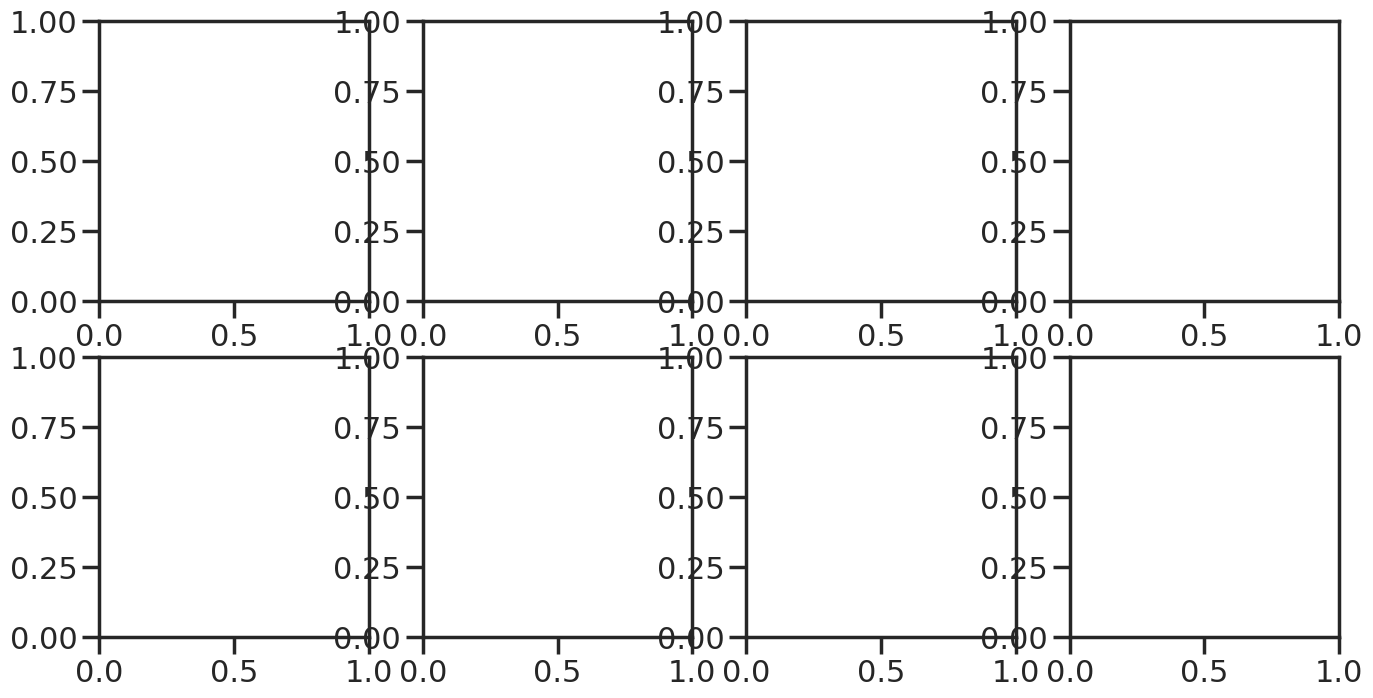

In [52]:
# #### gs: IS this the wrong cell? seems like it does NOT do the comsol piecewise thingy?
# #jenky solution to make this time colorbar the same as the comsol one for the S2 sweep at the bottom of this notebook
# tmepdf = processDF('20260416_S2/atp_S2_22.txt')
# global_time=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min(), tmepdf['time (s)'].min()]), vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max(), tmepdf['time (s)'].max()]))(time))


# fig, ax = plt.subplots(2,4, figsize=(16, 8))
# # for t, time in enumerate(h5dic_pc['timesMot'][:155]):
# #     ax[0,0].plot(h5dic_pc['all_rMotbins'][0],
# #              all_rMTavgs[::4][t], 
# #              alpha=1,
# #              lw=2,
# #              color=global_time(time))
# #     ax[0,1].plot(h5dic_pc['all_rMotbins'][0],
# #              bf[t], 
# #              alpha=1,
# #              lw=2,
# #              color=global_time(time))
# #     ax[0,2].plot(h5dic_pc['all_rMotbins'][0],
# #              2*h5dic_pc['all_rMotavgs'][t]*bf[t], 
# #              alpha=1,
# #              lw=2,
# #              color=global_time(time))
# #     ax[0,3].plot(h5dic_pc['all_rMotbins'][0],
# #              2*h5dic_pc['all_rMotavgs'][t], 
# #              alpha=1,
# #              lw=2,
# #              color=global_time(time))

# ### Tubulin ###
# #a = exponential(timesMT, 32, 475, 0.5)
# a = exponential(timesMT, 100, 250, 15)
# #b = exponential(timesMT, -18.23648431, 666.95695336,  17.32635126)
# b = exponential(timesMT, -17, 660, 17)#-18, 660, 17)
# c = exponential(timesMT, -120, 2000, 140)
# d = 0.6
# g = exponential(timesMT,  -18, 820, 18)#-20, 807, 18)
# #g = exponential(timesMT, -24.64547175, 617.2580981,   17.32786614)
# h = 80

# ### Motor ###
# mlocparams = [194.51312176, 880.75748941,  22.53829382]
# mheightparams = [-1.15971966e-07,  1.04668655e-03, -4.54772851e-01, 0]
# mtauparams =[-7.51645693e-07,  7.53363485e-03,  2.22451989e+00, 0]
# minfparams = [-2.41640883e-05,  6.17926972e-01]
# fitpeakval = quadratic(h5dic_pc['timesMot'][:155], *mheightparams)
# fitpeakloc = exponential(h5dic_pc['timesMot'][:155], *mlocparams)
# fitdecayconst = quadratic(h5dic_pc['timesMot'][:155], *mtauparams)
# fitinfval = linear(h5dic_pc['timesMot'][:155], *minfparams)

# for t, time in enumerate(h5dic_pc['timesMot'][:155]):
#     if t%5==0:
#         tubf = crazyftn(all_rMTbins[t,:], a[t], b[t], c[t], d, g[t], h)
#         motf = 2*sigmoid(all_rMTbins[t,:], fitpeakval[t], fitpeakloc[t], fitdecayconst[t], fitinfval[t])
#         bf_trial = boundfrac(motf, 13*tubf, 60)
#         ax[1,0].plot(all_rMTbins[t,:],
#                  tubf, 
#                  alpha=1,
#                  lw=2,
#                  color=global_time(time))
#         ax[1,1].plot(h5dic_pc['all_rMotbins'][0],
#                  bf_trial, 
#                  alpha=1,
#                  lw=2,
#                  color=global_time(time))
#         ax[1,2].plot(h5dic_pc['all_rMotbins'][0],
#                  motf*bf_trial, 
#                  alpha=1,
#                  lw=2,
#                  color=global_time(time))
#         ax[1,3].plot(h5dic_pc['all_rMotbins'][0],
#                  motf, 
#                  alpha=1,
#                  lw=2,
#                  color=global_time(time))
# ax[0,0].set_title('tubulin (µM)')
# ax[0,1].set_title('bound frac')
# ax[0,2].set_title('bound mot (µM)')
# ax[0,3].set_title('motors (µM)')

# ax[0,0].set_ylabel('data')
# ax[1,0].set_ylabel('trial function')

# ax[1,0].set_ylim(ax[0,0].get_ylim())
# ax[1,1].set_ylim(ax[0,1].get_ylim())
# ax[0,2].set_ylim(ax[1,2].get_ylim())
# ax[0,3].set_ylim(ax[1,3].get_ylim())

# ######
# # Adjust the top margin to make space for the colorbar
# fig.subplots_adjust(top=0.85)

# # Create an axis for the colorbar that spans all columns
# cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # [left, bottom, width, height]

# # Create the colorbar
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min(), tmepdf['time (s)'].min()])/60, vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max(), tmepdf['time (s)'].max()])/60)),
#                     cax=cax, orientation='horizontal')
# cbar.ax.tick_params(labelsize=20)

# # Move colorbar label and ticks to the top
# cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
# cbar.ax.xaxis.set_label_position('top')   # Move label to top
# cbar.set_label('time (min)', fontsize=25, labelpad=10)


# fig.supxlabel('radius (µm)')

# fig.tight_layout()

# #plt.savefig('../../analyzed_data/aster/20260401_R2_norecycling_647MT_unlabelledNcDmotors/tubMotBound.pdf', bbox_inches='tight')#, transparent=True)

#### WAIT what

In [ ]:
#20260516 Comsol parameters match the motor fit in the 20250315_asterVis.ipnb --> so i am plotting those parameters here
#jenky solution to make this time colorbar the same as the comsol one for the S2 sweep at the bottom of this notebook
tmepdf = processDF('20260416_S2/atp_S2_22.txt')
global_time=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min(), tmepdf['time (s)'].min()]), vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max(), tmepdf['time (s)'].max()]))(time))


fig, ax = plt.subplots(2,4, figsize=(16, 8))
for t, time in enumerate(h5dic_pc['timesMot'][:155]):
    ax[0,0].plot(h5dic_pc['all_rMotbins'][0],
             all_rMTavgs[::4][t], 
             alpha=1,
             lw=2,
             color=global_time(time))
    ax[0,1].plot(h5dic_pc['all_rMotbins'][0],
             bf[t], 
             alpha=1,
             lw=2,
             color=global_time(time))
    ax[0,2].plot(h5dic_pc['all_rMotbins'][0],
             2*h5dic_pc['all_rMotavgs'][t]*bf[t], 
             alpha=1,
             lw=2,
             color=global_time(time))
    ax[0,3].plot(h5dic_pc['all_rMotbins'][0],
             2*h5dic_pc['all_rMotavgs'][t], 
             alpha=1,
             lw=2,
             color=global_time(time))

### Tubulin ###
#a = exponential(timesMT, 32, 475, 0.5)
a = exponential(timesMT, 100, 250, 15)
#b = exponential(timesMT, -18.23648431, 666.95695336,  17.32635126)
b = exponential(timesMT, -17, 660, 17)#-18, 660, 17)
c = exponential(timesMT, -120, 2000, 140)
d = 0.6
g = exponential(timesMT,  -18, 820, 18)#-20, 807, 18)
#g = exponential(timesMT, -24.64547175, 617.2580981,   17.32786614)
h = 80

### Motor ###
mlocparams = [252, 630,  33]
mheightparams = [-2.16e-07,  1.32e-03, -5.7e-01, 0]
mtauparams =[-5.96e-07,  4.3e-03,  8.3e+00, 0]
minfparams = [-5e-06,  5.68e-01]
fitpeakval = quadratic(h5dic_pc['timesMot'][:155], *mheightparams)
fitpeakloc = exponential(h5dic_pc['timesMot'][:155], *mlocparams)
fitdecayconst = quadratic(h5dic_pc['timesMot'][:155], *mtauparams)
fitinfval = linear(h5dic_pc['timesMot'][:155], *minfparams)

for t, time in enumerate(h5dic_pc['timesMot'][:155]):
    if t%5==0:
        tubf = crazyftn(all_rMTbins[t,:], a[t], b[t], c[t], d, g[t], h)
        motf = 2*sigmoid(all_rMTbins[t,:], fitpeakval[t], fitpeakloc[t], fitdecayconst[t], fitinfval[t])

        if t<5: #comsol piecewise for MT is 90 seconds
            tubf = crazyftn(all_rMTbins[5,:], a[5], b[5], c[5], d, g[5], h)
        if t<24:
            motf = 2*sigmoid(all_rMTbins[24,:], fitpeakval[24], fitpeakloc[24], fitdecayconst[24], fitinfval[24])
            
        bf_trial = boundfrac(motf, 13*tubf, 60)
        ax[1,0].plot(all_rMTbins[t,:],
                 tubf, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
        ax[1,1].plot(h5dic_pc['all_rMotbins'][0],
                 bf_trial, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
        ax[1,2].plot(h5dic_pc['all_rMotbins'][0],
                 motf*bf_trial, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
        ax[1,3].plot(h5dic_pc['all_rMotbins'][0],
                 motf, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
ax[0,0].set_title('tubulin (µM)')
ax[0,1].set_title('bound frac')
ax[0,2].set_title('bound mot (µM)')
ax[0,3].set_title('motors (µM)')

ax[0,0].set_ylabel('data')
ax[1,0].set_ylabel('trial function')

ax[1,0].set_ylim(ax[0,0].get_ylim())
ax[1,1].set_ylim(ax[0,1].get_ylim())
ax[0,2].set_ylim(ax[1,2].get_ylim())
ax[0,3].set_ylim(ax[1,3].get_ylim())

######
# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # [left, bottom, width, height]

# Create the colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min(), tmepdf['time (s)'].min()])/60, vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max(), tmepdf['time (s)'].max()])/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)


fig.supxlabel('radius (µm)')

fig.tight_layout()

#plt.savefig('../../analyzed_data/aster/20260401_R2_norecycling_647MT_unlabelledNcDmotors/tubMotBound_20260516.pdf', bbox_inches='tight')#, transparent=True)

## Abandon the frustrating effort of understanding what happened with the above, and just endeavor a minimal reconstruction

In [54]:
def tubf(r, t):
    # Freeze tubulin profile at t = 90 s for earlier times
    if t < 90:
        t = 90

    a = 100*np.exp(-t/250) + 15
    b = -17*np.exp(-t/660) + 17
    c = -120*np.exp(-t/2000) + 140
    d = 0.6
    g = -18*np.exp(-t/807) + 18
    h = 80

    right = 1/(1 + np.exp(-100*(r-a))) * (
        (b-d)*np.exp(-(r-a)**2/c) + d
    )

    left = 1/(1 + np.exp(100*(r-a))) * (
        (b-g)*np.exp(-(r-a)**2/h) + g
    )

    return right + left


def motf(r, t):
    # Freeze motor profile at t = 480 s for earlier times
    if t < 480:
        t = 480

    peak = -2.16e-7*t**2 + 1.32e-3*t - 0.57
    loc  = 252*np.exp(-t/630) + 33
    tau  = -5.96e-7*t**2 + 4.3e-3*t + 8.3
    inf  = -5e-6*t + 0.568

    return 2 * (
        peak / (1 + np.exp((r-loc)/tau))
        + inf
    )

In [58]:
h5dic_pc['timesATP'][-1]

np.float64(3970.0)

In [61]:
h5dic_pc['all_rATPbins'][-1]*6*um_per_pixel

array([  2.19724138,   6.59172414,  10.9862069 ,  15.38068966,
        19.77517241,  24.16965517,  28.56413793,  32.95862069,
        37.35310345,  41.74758621,  46.14206897,  50.53655172,
        54.93103448,  59.32551724,  63.72      ,  68.11448276,
        72.50896552,  76.90344828,  81.29793103,  85.69241379,
        90.08689655,  94.48137931,  98.87586207, 103.27034483,
       107.66482759, 112.05931034, 116.4537931 , 120.84827586,
       125.24275862])

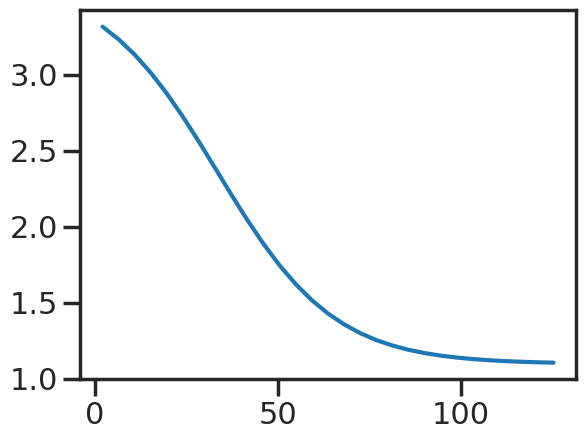

In [63]:
plt.plot(h5dic_pc['all_rATPbins'][-1]*6*um_per_pixel, 
         motf(h5dic_pc['all_rATPbins'][-1]*6*um_per_pixel, h5dic_pc['timesATP'][-1])
        )
# plt.ylim([0, plt.ylim()[-1]])

/home/aduarte/am_atp/analysis/aster/ipykernel_382349/2947490108.py:13: RuntimeWarning: overflow encountered in exp
  right = 1/(1 + np.exp(-100*(r-a))) * (
/home/aduarte/am_atp/analysis/aster/ipykernel_382349/2947490108.py:17: RuntimeWarning: overflow encountered in exp
  left = 1/(1 + np.exp(100*(r-a))) * (


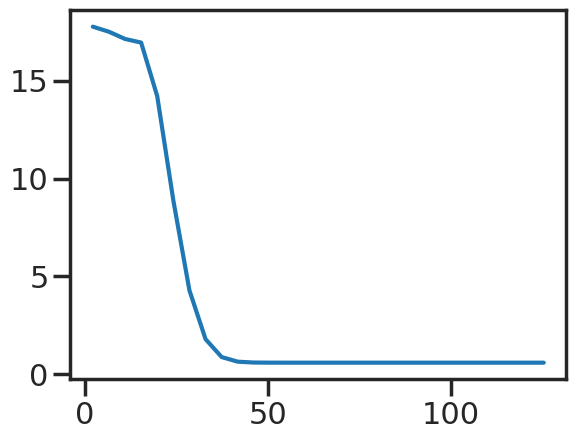

In [64]:
plt.plot(h5dic_pc['all_rATPbins'][-1]*6*um_per_pixel, 
         tubf(h5dic_pc['all_rATPbins'][-1]*6*um_per_pixel, h5dic_pc['timesATP'][-1])
        )
# plt.ylim([0, plt.ylim()[-1]])

/home/aduarte/am_atp/analysis/aster/ipykernel_382349/2947490108.py:13: RuntimeWarning: overflow encountered in exp
  right = 1/(1 + np.exp(-100*(r-a))) * (
/home/aduarte/am_atp/analysis/aster/ipykernel_382349/2947490108.py:17: RuntimeWarning: overflow encountered in exp
  left = 1/(1 + np.exp(100*(r-a))) * (


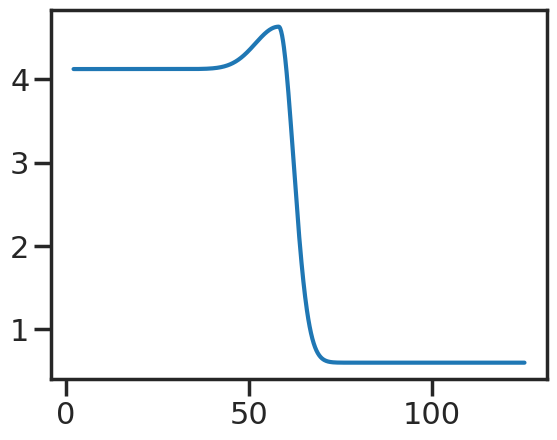

In [70]:
smooth_radii=np.linspace(radii[0], radii[-1], 1000)
plt.plot(smooth_radii, 
         tubf(smooth_radii, h5dic_pc['timesATP'][10])
        )


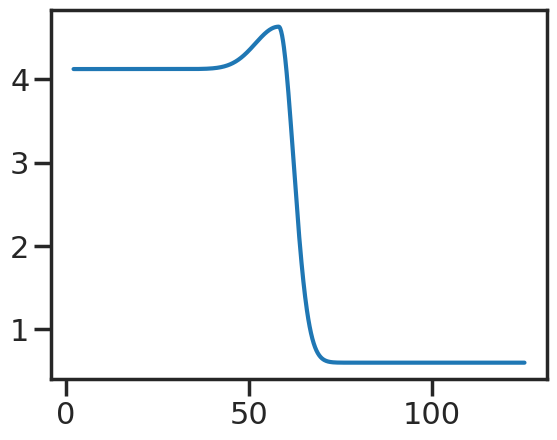

In [71]:
### slightly numerically safer
from scipy.special import expit

def tubf(r, t):
    # Freeze tubulin profile at t = 90 s for earlier times
    if t < 90:
        t = 90

    a = 100*np.exp(-t/250) + 15
    b = -17*np.exp(-t/660) + 17
    c = -120*np.exp(-t/2000) + 140
    d = 0.6
    g = -18*np.exp(-t/807) + 18
    h = 80

    # Numerically stable left/right switching
    right_switch = expit(100*(r - a))
    left_switch  = expit(-100*(r - a))

    right = right_switch * (
        (b - d)*np.exp(-(r - a)**2 / c) + d
    )

    left = left_switch * (
        (b - g)*np.exp(-(r - a)**2 / h) + g
    )

    return right + left

smooth_radii=np.linspace(radii[0], radii[-1], 1000)
plt.plot(smooth_radii, 
         tubf(smooth_radii, h5dic_pc['timesATP'][10])
        )
